In [2]:
import os
import torch
from PIL import Image
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models, datasets
from tqdm import tqdm
import torch.nn as nn

In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

CUDA available: True
Device name: NVIDIA GeForce RTX 4070


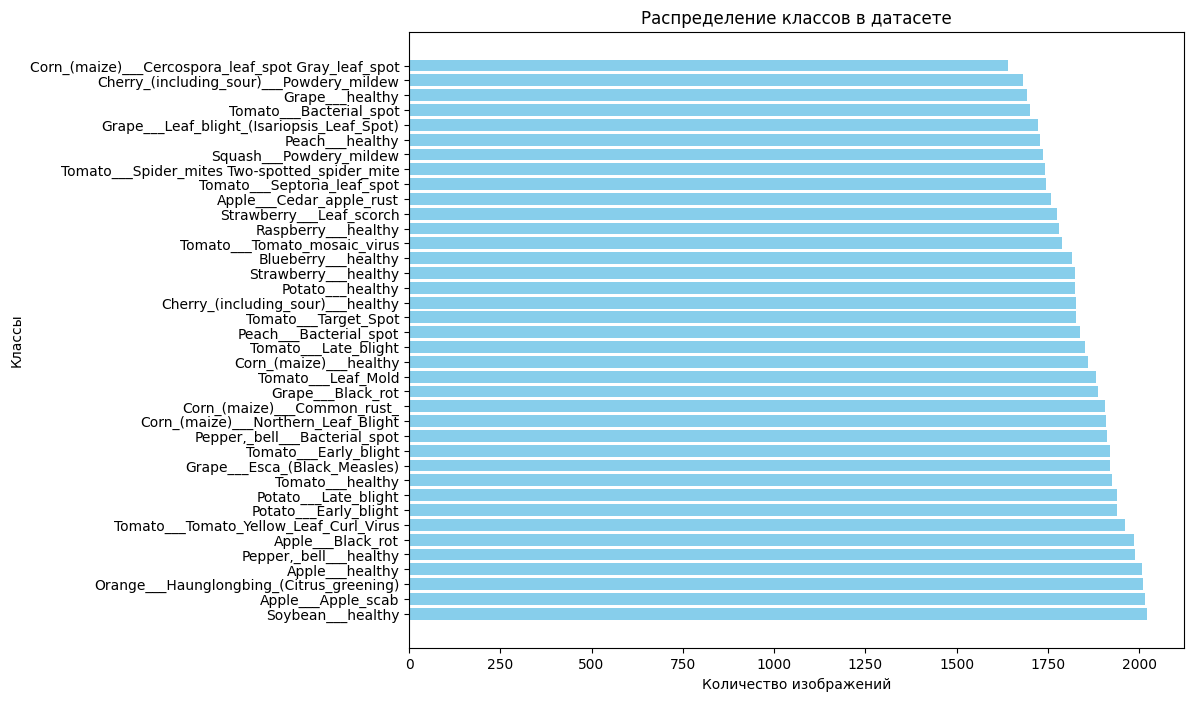

In [ ]:
import os
import matplotlib.pyplot as plt
from collections import Counter

train_dir = "C:/PythonProjects/plant_disease_class/new_plant/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"

class_names = os.listdir(train_dir)

class_counts = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        image_count = len(os.listdir(class_path)) 
        class_counts.append((class_name, image_count))

class_counts.sort(key=lambda x: x[1], reverse=True)

class_names_sorted = [x[0] for x in class_counts]
counts_sorted = [x[1] for x in class_counts]

plt.figure(figsize=(10, 8))
plt.barh(class_names_sorted, counts_sorted, color='skyblue')
plt.xlabel('Количество изображений')
plt.ylabel('Классы')
plt.title('Распределение классов в датасете')
plt.show()


In [3]:
class ImageClassificationDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        for label_name in os.listdir(image_dir):
            label_folder = os.path.join(image_dir, label_name)
            if os.path.isdir(label_folder):
                for img_name in os.listdir(label_folder):
                    img_path = os.path.join(label_folder, img_name)
                    if img_path.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.image_paths.append(img_path)
                        self.labels.append(label_name)

        self.classes = sorted(set(self.labels))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label_name = self.labels[idx]
        label = self.class_to_idx[label_name] 
        img = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img) 

        return img, label

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dir = "C:/PythonProjects/plant_disease_class/new_plant/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
val_dir = "C:/PythonProjects/plant_disease_class/new_plant/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

train_dataset = ImageClassificationDataset(train_dir, transform=transform)
val_dataset = ImageClassificationDataset(val_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

model = models.resnet50(pretrained=True)

num_classes = len(train_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    best_val_accuracy = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            _, preds = torch.max(outputs, 1)
            correct_train += torch.sum(preds == labels.data)
            total_train += labels.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_accuracy = correct_train.double() / total_train

        print(f"Train Loss: {epoch_loss:.4f} | Train Accuracy: {epoch_accuracy:.4f}")

        model.eval()
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                correct_val += torch.sum(preds == labels.data)
                total_val += labels.size(0)

        val_accuracy = correct_val.double() / total_val
        print(f"Validation Accuracy: {val_accuracy:.4f}")

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"Model saved with accuracy {val_accuracy:.4f}")


    print("Training complete")

train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10)

c:\PythonProjects\plant_disease_class\venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\PythonProjects\plant_disease_class\venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\admin/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:11<00:00, 8.75MB/s]
Epoch 1/10: 100%|██████████| 2197/2197 [10:24<00:00,  3.52it/s]


Train Loss: 0.3780 | Train Accuracy: 0.8807
Validation Accuracy: 0.9482
Model saved with accuracy 0.9482


Epoch 2/10: 100%|██████████| 2197/2197 [06:27<00:00,  5.68it/s]


...

Train Loss: 0.0309 | Train Accuracy: 0.9898
Validation Accuracy: 0.9891


Epoch 9/10: 100%|██████████| 2197/2197 [05:46<00:00,  6.33it/s]


Train Loss: 0.0264 | Train Accuracy: 0.9917
Validation Accuracy: 0.9903


Epoch 10/10: 100%|██████████| 2197/2197 [05:52<00:00,  6.24it/s]


Train Loss: 0.0240 | Train Accuracy: 0.9919
Validation Accuracy: 0.9903
Training complete


In [19]:
test_dir = "C:/PythonProjects/plant_disease_class/new_plant/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = ImageClassificationDataset(test_dir, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Testing"):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            correct += torch.sum(preds == labels.data)
            total += labels.size(0)

    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")
    return accuracy

test_model(model, test_loader)

Testing: 100%|██████████| 550/550 [00:32<00:00, 16.90it/s]


Test Accuracy: 0.9903


tensor(0.9903, device='cuda:0')

PPPPPPPPPPPPPPPPPPP  32


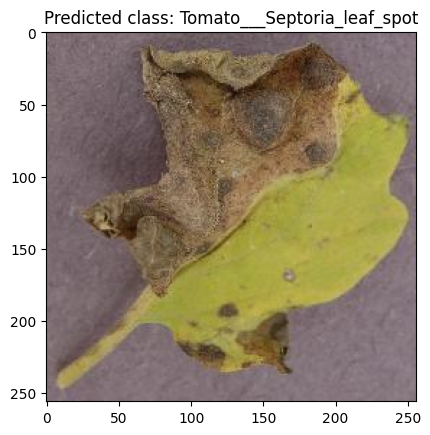

In [23]:
from PIL import Image
import matplotlib.pyplot as plt

def predict_image(image_path, model, transform):
    model.eval()
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0) 
    image = image.to(device)

    with torch.no_grad():
        output = model(image)
        _, pred = torch.max(output, 1)
        print("PPPPPPPPPPPPPPPPPPP ", pred.item())
        pred_class = train_dataset.classes[pred.item()] 

    return pred_class

image_path = 'C:/PythonProjects/plant_disease_class/0c8fd2f4-9c26-4e6d-90b5-fae10602579c___Matt.S_CG 1072.JPG'
predicted_class = predict_image(image_path, model, test_transform)

image = Image.open(image_path)
plt.imshow(image)
plt.title(f"Predicted class: {predicted_class}")
plt.show()


In [27]:
print(train_dataset.classes)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [ ]:
import torch
import torch.nn as nn
from torchvision import models


def load_model_from_pth(model_path, train_dataset, device):
    model = models.resnet50(pretrained=False)  
    num_classes = len(train_dataset.classes)
    model.fc = nn.Linear(model.fc.in_features, num_classes)  
    model.load_state_dict(torch.load(model_path, map_location=device))  
    model.to(device)
    model.eval()  
    return model


def save_model_as_pt(model, model_path):
    torch.save(model, model_path)  
    print(f"Model saved to {model_path}")

train_dir = "C:/PythonProjects/plant_disease_class/new_plant/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
val_dir = "C:/PythonProjects/plant_disease_class/new_plant/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageClassificationDataset(train_dir, transform=transform)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = load_model_from_pth('best_model.pth', train_dataset, device)


save_model_as_pt(model, 'best_model.pt')

c:\PythonProjects\plant_disease_class\venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\PythonProjects\plant_disease_class\venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model saved to best_model.pt


In [ ]:
import torch
import torch.nn as nn
from torchvision import models
import torch.onnx
from torch.utils.data import DataLoader
from torchvision import transforms
import onnx

def load_model_from_pth(model_path, train_dataset, device):
    model = models.resnet50(pretrained=False)
    num_classes = len(train_dataset.classes)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model

def save_model_as_onnx(model, model_path, input_size=(1, 3, 224, 224), device='cpu'):

    dummy_input = torch.randn(input_size).to(device)
    torch.onnx.export(model, dummy_input, model_path, verbose=True, input_names=['input'], output_names=['output'])
    print(f"Model saved to {model_path}")

train_dir = "C:/PythonProjects/plant_disease_class/new_plant/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
val_dir = "C:/PythonProjects/plant_disease_class/new_plant/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageClassificationDataset(train_dir, transform=transform)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = load_model_from_pth('best_model.pth', train_dataset, device)

save_model_as_onnx(model, 'best_model.onnx', input_size=(1, 3, 224, 224), device=device)

onnx_model = onnx.load("best_model.onnx")
onnx.checker.check_model(onnx_model)
print("ONNX model is valid!")


c:\PythonProjects\plant_disease_class\venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\PythonProjects\plant_disease_class\venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model saved to best_model.onnx
ONNX model is valid!


Predicted class index: 29


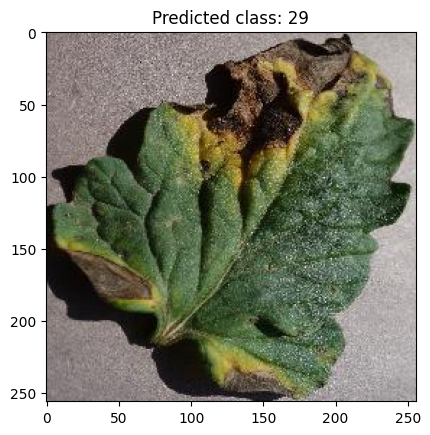

In [ ]:
import onnxruntime as ort
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms

def load_onnx_model(onnx_model_path):

    session = ort.InferenceSession(onnx_model_path)
    return session

def predict_image_onnx(image_path, session, transform):
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0) 
    image = image.numpy() 


    input_name = session.get_inputs()[0].name 
    output_name = session.get_outputs()[0].name 
    predictions = session.run([output_name], {input_name: image})[0] 


    pred = predictions.argmax(axis=1)
    pred_class = pred.item()
    
    return pred_class

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

onnx_model_path = 'best_model.onnx' 
session = load_onnx_model(onnx_model_path)

image_path = 'C:/PythonProjects/plant_disease_class/Tomato___Early_blight1.JPG'

predicted_class = predict_image_onnx(image_path, session, test_transform)

print(f"Predicted class index: {predicted_class}")

image = Image.open(image_path)
plt.imshow(image)
plt.title(f"Predicted class: {predicted_class}")
plt.show()
